In [10]:
# =============================================================
# NEXUSCOMMERCE — FINAL DEMAND FORECASTING PIPELINE
# XGBoost + Optuna Hyperparameter Tuning
# =============================================================
# Single-model approach. XGBoost won the model bake-off on this
# data with R² = 0.940 on the largest series. Optuna pushes that
# further by searching the hyperparameter space.
# =============================================================
 
 
# =============================================================
# CELL 1: INSTALL DEPENDENCIES (run once, then restart kernel)
# =============================================================
!pip install -q xgboost optuna --upgrade
#
# After install: Run → Restart & Clear Output, then proceed.

In [11]:

# =============================================================
# CELL 2: IMPORTS & CONFIG
# =============================================================
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
 
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)
 
# ── Config ───────────────────────────────────────────────────
TRAIN_CSV   = '/kaggle/input/datasets/abdullahkhan001187/online5/uci_training_data.csv'
VAL_CSV     = '/kaggle/input/datasets/abdullahkhan001187/online5/superstore_validation_data.csv'
 
OUTPUT_DIR  = 'models'
RESULTS_DIR = 'results'
 
TEST_SPLIT     = 0.20
TOP_N_CATS     = 5
N_OPTUNA_TRIALS = 50      # 50 trials per category (~3-5 min each on GPU)
N_CV_FOLDS     = 3        # 3-fold time-series CV during tuning
 
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
 
print(f"XGBoost : {xgb.__version__}")
print(f"Optuna  : {optuna.__version__}")
print(f"Trials per category: {N_OPTUNA_TRIALS}")
 

XGBoost : 3.2.0
Optuna  : 4.8.0
Trials per category: 50


In [12]:

# =============================================================
# CELL 3: LOAD DATA & AGGREGATE PER CATEGORY
# =============================================================
print("=" * 60)
print("LOADING DATA")
print("=" * 60)
 
df = pd.read_csv(TRAIN_CSV)
df['sale_date'] = pd.to_datetime(df['sale_date'])
 
print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['sale_date'].min()} → {df['sale_date'].max()}")
 
daily_cat = (df
    .groupby(['category', 'sale_date'])
    .agg(
        quantity  = ('quantity', 'sum'),
        revenue   = ('revenue',  'sum'),
        avg_price = ('price',    'mean'),
        n_orders  = ('quantity', 'count'),
    )
    .reset_index()
)
 
top_cats = (daily_cat
    .groupby('category')['quantity'].sum()
    .sort_values(ascending=False)
    .head(TOP_N_CATS)
    .index.tolist()
)
daily_cat = daily_cat[daily_cat['category'].isin(top_cats)]
 
print(f"\nTop {TOP_N_CATS} categories selected:")
for c in top_cats:
    n = (daily_cat['category'] == c).sum()
    print(f"   {c:25s} | {n} days")
 
 

LOADING DATA
Loaded 930,329 rows
Date range: 2009-12-01 00:00:00 → 2011-12-09 00:00:00

Top 5 categories selected:
   United Kingdom            | 604 days
   Germany                   | 381 days
   EIRE                      | 322 days
   France                    | 331 days
   Spain                     | 118 days


In [13]:

# =============================================================
# CELL 4: FEATURE ENGINEERING
# =============================================================
def build_features(category: str) -> pd.DataFrame:
    """
    Comprehensive feature set:
      ▸ Calendar features (10)
      ▸ Cyclical encodings (6)
      ▸ Lag features (10)
      ▸ Rolling statistics at 5 windows (25)
      ▸ EWMA features (4)
      ▸ Trend differences (3)
      ▸ Lag ratios (2)
    Total: ~60 features
    """
    cat_df = (daily_cat[daily_cat['category'] == category]
              .sort_values('sale_date')
              .copy())
 
    # Fill missing days
    full_idx = pd.date_range(
        start=cat_df['sale_date'].min(),
        end=cat_df['sale_date'].max(),
        freq='D'
    )
    cat_df = (cat_df
              .set_index('sale_date')
              .reindex(full_idx, fill_value=0)
              .rename_axis('sale_date')
              .reset_index())
 
    d = cat_df['sale_date'].dt
    cat_df['day_of_week']    = d.dayofweek
    cat_df['day_of_month']   = d.day
    cat_df['day_of_year']    = d.dayofyear
    cat_df['week_of_year']   = d.isocalendar().week.astype(int)
    cat_df['month']          = d.month
    cat_df['quarter']        = d.quarter
    cat_df['year']           = d.year
    cat_df['is_weekend']     = (d.dayofweek >= 5).astype(int)
    cat_df['is_month_start'] = d.is_month_start.astype(int)
    cat_df['is_month_end']   = d.is_month_end.astype(int)
    cat_df['is_quarter_end'] = d.is_quarter_end.astype(int)
 
    # Cyclical encoding
    cat_df['dow_sin']   = np.sin(2*np.pi*cat_df['day_of_week']/7)
    cat_df['dow_cos']   = np.cos(2*np.pi*cat_df['day_of_week']/7)
    cat_df['month_sin'] = np.sin(2*np.pi*cat_df['month']/12)
    cat_df['month_cos'] = np.cos(2*np.pi*cat_df['month']/12)
    cat_df['doy_sin']   = np.sin(2*np.pi*cat_df['day_of_year']/365)
    cat_df['doy_cos']   = np.cos(2*np.pi*cat_df['day_of_year']/365)
 
    # Lag features
    for lag in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]:
        cat_df[f'lag_{lag}'] = cat_df['quantity'].shift(lag)
 
    # Rolling statistics
    for window in [3, 7, 14, 28, 56]:
        roll = cat_df['quantity'].shift(1).rolling(window, min_periods=1)
        cat_df[f'roll_mean_{window}']   = roll.mean()
        cat_df[f'roll_std_{window}']    = roll.std().fillna(0)
        cat_df[f'roll_min_{window}']    = roll.min()
        cat_df[f'roll_max_{window}']    = roll.max()
        cat_df[f'roll_median_{window}'] = roll.median()
 
    # EWMA
    for span in [3, 7, 14, 28]:
        cat_df[f'ewm_{span}'] = (cat_df['quantity'].shift(1)
                                 .ewm(span=span, adjust=False).mean())
 
    # Trend
    cat_df['trend_7']  = cat_df['quantity'].shift(1) - cat_df['quantity'].shift(8)
    cat_df['trend_14'] = cat_df['quantity'].shift(1) - cat_df['quantity'].shift(15)
    cat_df['trend_28'] = cat_df['quantity'].shift(1) - cat_df['quantity'].shift(29)
 
    # Lag ratios
    cat_df['lag1_over_roll7']  = cat_df['lag_1'] / (cat_df['roll_mean_7']  + 1)
    cat_df['lag7_over_roll28'] = cat_df['lag_7'] / (cat_df['roll_mean_28'] + 1)
 
    return cat_df.dropna().reset_index(drop=True)
 
 
def split_train_test(series_df, pct=TEST_SPLIT):
    n_test = int(len(series_df) * pct)
    return series_df.iloc[:-n_test].copy(), series_df.iloc[-n_test:].copy()
 
 
EXCLUDE = ['sale_date', 'category', 'quantity', 'revenue']
 
demo = build_features(top_cats[0])
print(f"Features built: {demo.shape[1]} columns | {len(demo)} rows")
 

Features built: 67 columns | 710 rows


In [14]:

# =============================================================
# CELL 5: OPTUNA HYPERPARAMETER TUNING
# =============================================================
def objective(trial, X, y):
    """
    Optuna search space for XGBoost.
    Uses 3-fold time-series CV to pick the best configuration.
    """
    params = {
        'objective'        : 'reg:squarederror',
        'eval_metric'      : 'mae',
        'tree_method'      : 'hist',                 # fast histogram method
        'device'           : 'cuda',                 # GPU acceleration
 
        # Core tree structure
        'max_depth'        : trial.suggest_int('max_depth', 4, 12),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 20),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
 
        # Learning rate
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
 
        # Regularization
        'reg_alpha'        : trial.suggest_float('reg_alpha',  1e-3, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
 
        # Sampling
        'subsample'        : trial.suggest_float('subsample',        0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
 
        'random_state'     : 42,
        'verbosity'        : 0,
    }
 
    tscv = TimeSeriesSplit(n_splits=N_CV_FOLDS)
    fold_maes = []
 
    for tr_idx, val_idx in tscv.split(X):
        X_tr,  X_val = X[tr_idx], X[val_idx]
        y_tr,  y_val = y[tr_idx], y[val_idx]
 
        model = xgb.XGBRegressor(
            **params,
            n_estimators=2000,
            early_stopping_rounds=50,
        )
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
 
        preds = model.predict(X_val).clip(min=0)
        fold_maes.append(mean_absolute_error(y_val, preds))
 
    return np.mean(fold_maes)
 
 
def tune_xgboost(train_df, n_trials=N_OPTUNA_TRIALS):
    """
    Run Optuna search on the training data only.
    Returns the best parameter dictionary.
    """
    feat_cols = [c for c in train_df.columns if c not in EXCLUDE]
    X = train_df[feat_cols].values
    y = train_df['quantity'].values
 
    sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(
        lambda t: objective(t, X, y),
        n_trials=n_trials,
        show_progress_bar=False,
    )
    return study.best_params, study.best_value, feat_cols
 
 

In [15]:

# =============================================================
# CELL 6: TRAIN FINAL TUNED XGBOOST PER CATEGORY
# =============================================================
def train_final_xgboost(train_df, test_df, best_params):
    """
    Train final XGBoost on full training data using the
    best hyperparameters found by Optuna.
    """
    feat_cols = [c for c in train_df.columns if c not in EXCLUDE]
    X_train, y_train = train_df[feat_cols].values, train_df['quantity'].values
    X_test            = test_df[feat_cols].values
 
    # Hold last 15% of train for early stopping
    n_inner = max(int(len(X_train) * 0.15), 30)
    X_tr, X_val = X_train[:-n_inner], X_train[-n_inner:]
    y_tr, y_val = y_train[:-n_inner], y_train[-n_inner:]
 
    full_params = {
        **best_params,
        'objective'   : 'reg:squarederror',
        'eval_metric' : 'mae',
        'tree_method' : 'hist',
        'device'      : 'cuda',
        'random_state': 42,
        'verbosity'   : 0,
    }
 
    model = xgb.XGBRegressor(
        **full_params,
        n_estimators=3000,
        early_stopping_rounds=50,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
 
    preds = model.predict(X_test).clip(min=0)
    return preds, model, feat_cols
 
 

In [16]:

# =============================================================
# CELL 7: EVALUATION HELPER
# =============================================================
def evaluate(y_true, y_pred, model_name, category):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
            if mask.sum() else np.nan)
    return {
        'category': category, 'model': model_name,
        'mae': round(mae, 3), 'rmse': round(rmse, 3),
        'r2': round(r2, 3),
        'mape': round(mape, 2) if not np.isnan(mape) else None,
    }
 

In [17]:

# =============================================================
# CELL 8: TUNE + TRAIN ON ALL CATEGORIES
# =============================================================
all_results   = []
all_forecasts = {}
best_params_log = {}
 
print("\n" + "=" * 60)
print("TUNING + TRAINING XGBOOST")
print("=" * 60)
 
for cat in top_cats:
    print(f"\n{'─' * 60}")
    print(f"Category: {cat}")
    print(f"{'─' * 60}")
 
    series_df = build_features(cat)
    train_df, test_df = split_train_test(series_df)
 
    if len(train_df) < 120 or len(test_df) < 7:
        print(f"⚠  Skipping {cat} — insufficient data.")
        continue
 
    y_test = test_df['quantity'].values
 
    # ── Step 1: Optuna search for best hyperparameters ──────
    print(f"  Running Optuna with {N_OPTUNA_TRIALS} trials... ", end='', flush=True)
    best_params, best_cv_mae, feat_cols = tune_xgboost(train_df)
    best_params_log[cat] = {**best_params, 'cv_mae': round(best_cv_mae, 3)}
    print(f"done")
    print(f"  Best CV MAE        : {best_cv_mae:.3f}")
    print(f"  Best params:")
    for k, v in best_params.items():
        v_str = f"{v:.4f}" if isinstance(v, float) else str(v)
        print(f"     {k:20s}: {v_str}")
 
    # ── Step 2: Train final model on full data ──────────────
    print(f"  Training final model... ", end='', flush=True)
    preds, model, _ = train_final_xgboost(train_df, test_df, best_params)
    test_mae = mean_absolute_error(y_test, preds)
    test_r2  = r2_score(y_test, preds)
    print(f"done | Test MAE = {test_mae:.2f} | Test R² = {test_r2:.3f}")
 
    # ── Record results ──────────────────────────────────────
    all_results.append(evaluate(y_test, preds, 'XGBoost-Tuned', cat))
 
    all_forecasts[cat] = {
        'dates'    : test_df['sale_date'].values,
        'actual'   : y_test,
        'forecast' : preds,
    }
 
    # Save artifacts
    safe = cat.replace(' ', '_').replace('/', '_')
    joblib.dump(model,        f'{OUTPUT_DIR}/xgb_{safe}.pkl')
    joblib.dump(feat_cols,    f'{OUTPUT_DIR}/features_{safe}.pkl')
    joblib.dump(best_params,  f'{OUTPUT_DIR}/best_params_{safe}.pkl')
 


TUNING + TRAINING XGBOOST

────────────────────────────────────────────────────────────
Category: United Kingdom
────────────────────────────────────────────────────────────
  Running Optuna with 50 trials... done
  Best CV MAE        : 746.638
  Best params:
     max_depth           : 6
     min_child_weight    : 5
     gamma               : 1.0725
     learning_rate       : 0.1269
     reg_alpha           : 0.4796
     reg_lambda          : 0.0458
     subsample           : 0.7620
     colsample_bytree    : 0.9372
     colsample_bylevel   : 0.9314
  Training final model... done | Test MAE = 804.26 | Test R² = 0.930

────────────────────────────────────────────────────────────
Category: Germany
────────────────────────────────────────────────────────────
  Running Optuna with 50 trials... done
  Best CV MAE        : 24.835
  Best params:
     max_depth           : 9
     min_child_weight    : 1
     gamma               : 2.9590
     learning_rate       : 0.0476
     reg_alpha        

In [18]:

# =============================================================
# CELL 9: RESULTS TABLE
# =============================================================
results_df = pd.DataFrame(all_results)
results_df.to_csv(f'{RESULTS_DIR}/results.csv', index=False)
 
print("\n" + "=" * 60)
print("PER-CATEGORY RESULTS")
print("=" * 60)
print(results_df.to_string(index=False))
 
summary = (results_df[['mae', 'rmse', 'r2', 'mape']]
           .mean().round(3))
 
print("\n" + "=" * 60)
print("AVERAGE PERFORMANCE — TUNED XGBOOST")
print("=" * 60)
print(summary)
summary.to_csv(f'{RESULTS_DIR}/summary.csv')
 
# Save best params per category
params_df = pd.DataFrame(best_params_log).T
params_df.to_csv(f'{RESULTS_DIR}/best_params_per_category.csv')
print(f"\nBest hyperparameters saved to: {RESULTS_DIR}/best_params_per_category.csv")
 


PER-CATEGORY RESULTS
      category         model     mae     rmse    r2  mape
United Kingdom XGBoost-Tuned 804.258 1112.030 0.930 12.09
       Germany XGBoost-Tuned  27.645   63.206 0.954 22.82
          EIRE XGBoost-Tuned  32.285   72.576 0.929 37.81
        France XGBoost-Tuned  41.687   89.074 0.907 39.90
         Spain XGBoost-Tuned  16.008   51.742 0.802 49.37

AVERAGE PERFORMANCE — TUNED XGBOOST
mae     184.377
rmse    277.726
r2        0.904
mape     32.398
dtype: float64

Best hyperparameters saved to: results/best_params_per_category.csv


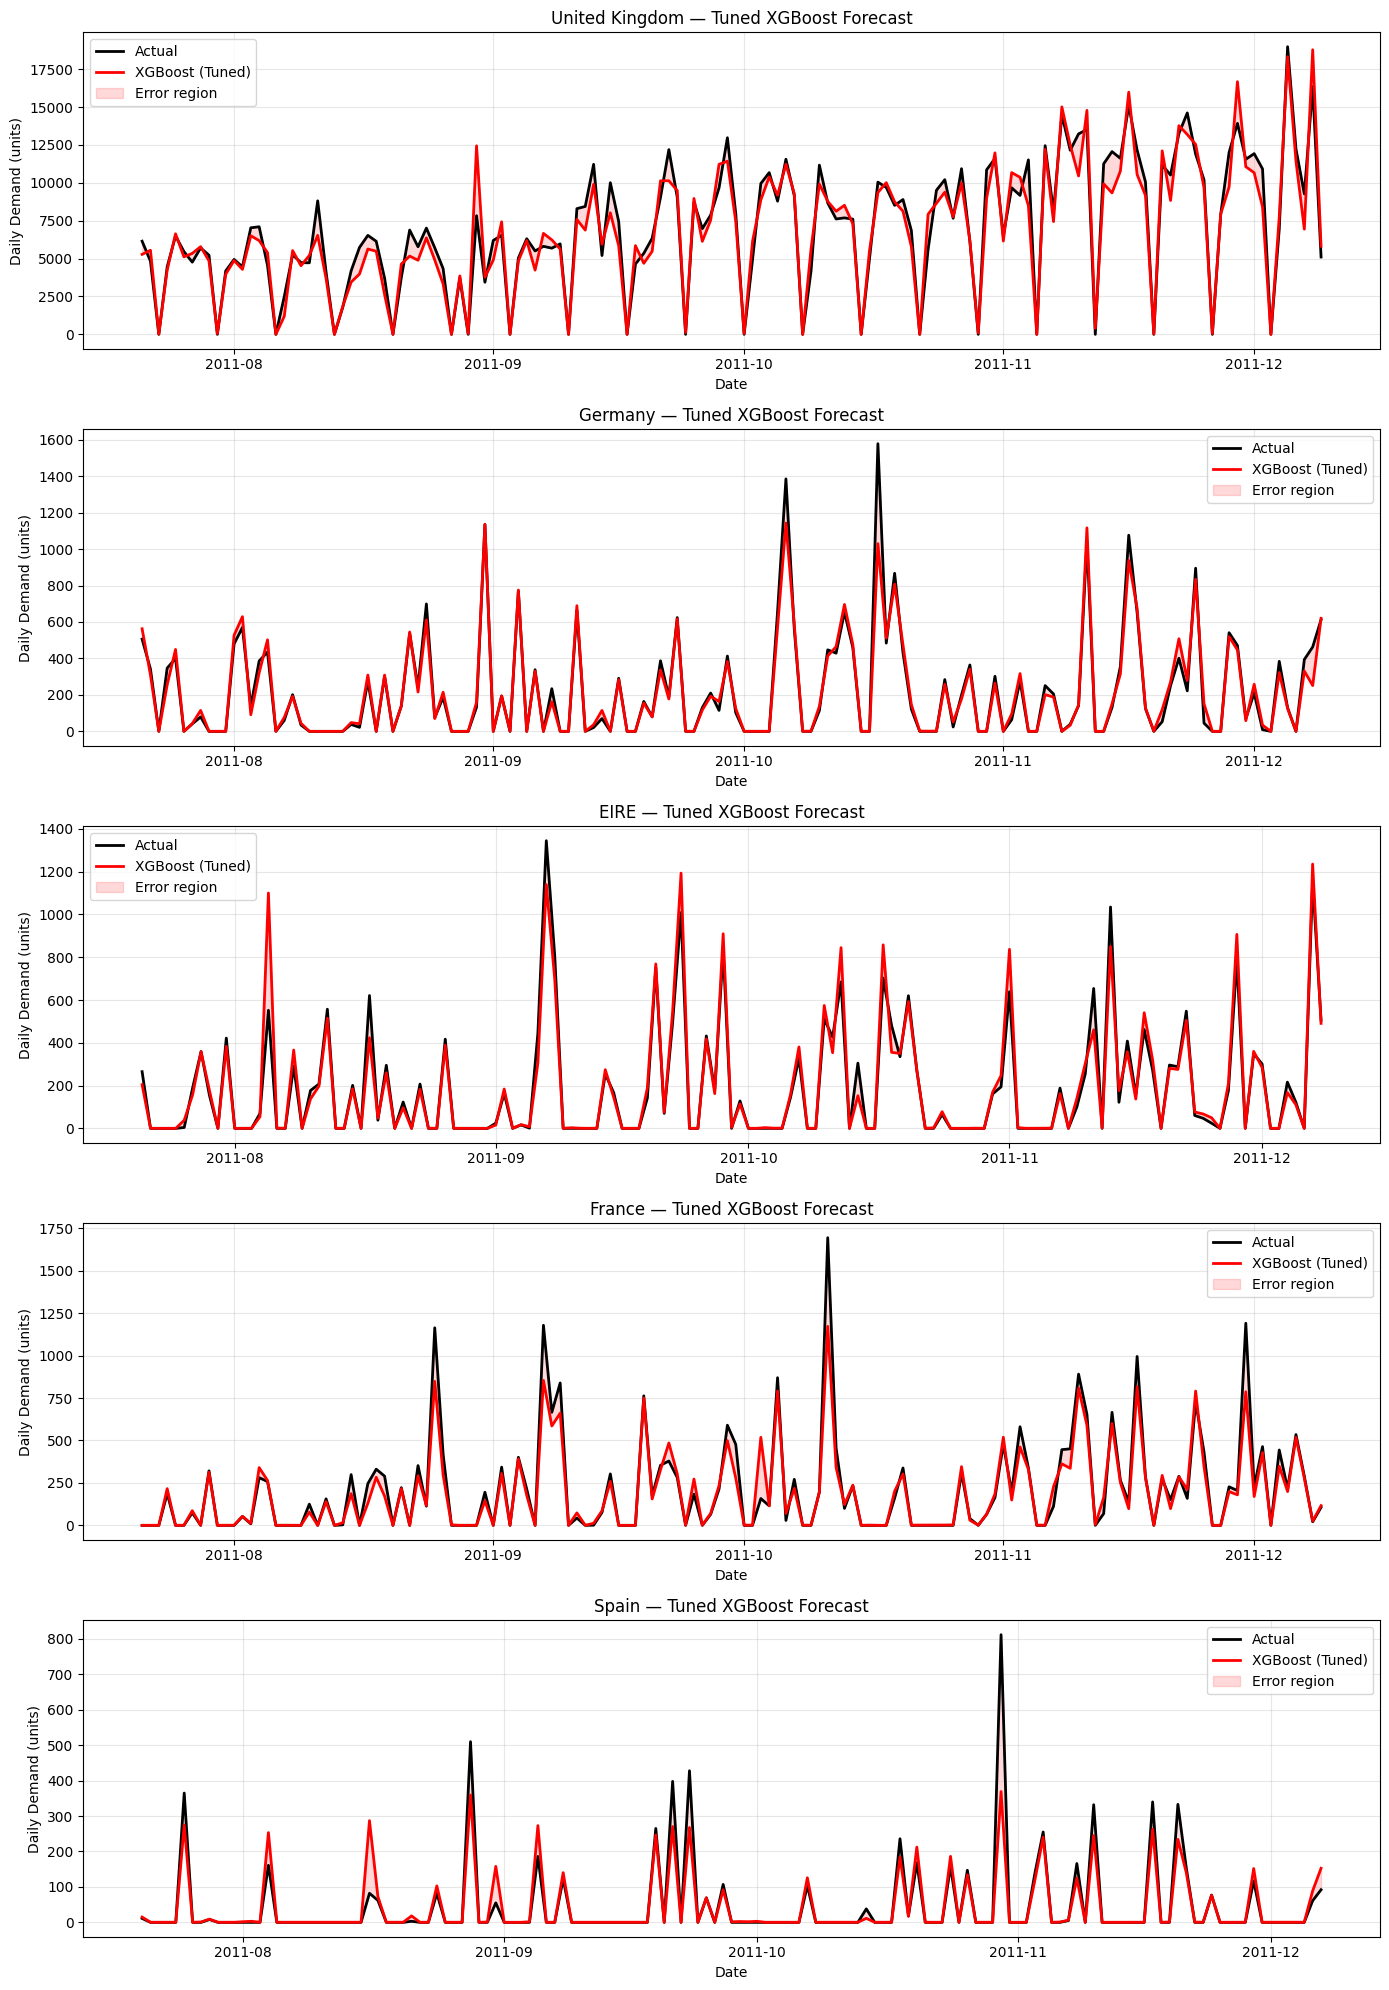

In [19]:

# =============================================================
# CELL 10: VISUALIZATION
# =============================================================
n = len(all_forecasts)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), squeeze=False)
 
for ax, (cat, fc) in zip(axes[:, 0], all_forecasts.items()):
    ax.plot(fc['dates'], fc['actual'],   label='Actual',
            linewidth=2, color='black')
    ax.plot(fc['dates'], fc['forecast'], label='XGBoost (Tuned)',
            linewidth=2, color='red')
    ax.fill_between(fc['dates'], fc['actual'], fc['forecast'],
                    alpha=0.15, color='red',
                    label='Error region')
    ax.set_title(f'{cat} — Tuned XGBoost Forecast')
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Demand (units)')
    ax.legend()
    ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/forecast_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()
 

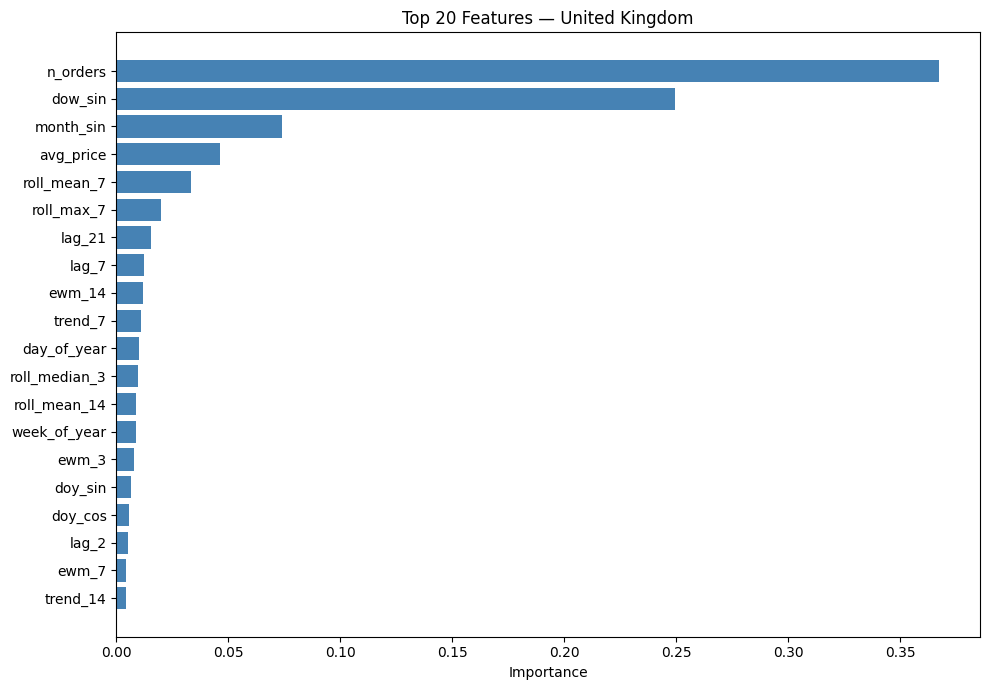


Top 10 most important features:
    feature  importance
   n_orders    0.367180
    dow_sin    0.249347
  month_sin    0.073752
  avg_price    0.046156
roll_mean_7    0.033378
 roll_max_7    0.019972
     lag_21    0.015650
      lag_7    0.012217
     ewm_14    0.012074
    trend_7    0.011078


In [20]:

# =============================================================
# CELL 11: FEATURE IMPORTANCE
# =============================================================
cat = top_cats[0]
safe = cat.replace(' ', '_').replace('/', '_')
m = joblib.load(f'{OUTPUT_DIR}/xgb_{safe}.pkl')
feats = joblib.load(f'{OUTPUT_DIR}/features_{safe}.pkl')
 
importance_df = (pd.DataFrame({
    'feature'   : feats,
    'importance': m.feature_importances_,
}).sort_values('importance', ascending=False).head(20))
 
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color='steelblue')
ax.set_title(f'Top 20 Features — {cat}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
 
print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))
 

In [21]:

# =============================================================
# CELL 12: CROSS-DATASET VALIDATION ON SUPERSTORE
# =============================================================
print("\n" + "=" * 60)
print("CROSS-DATASET VALIDATION — SUPERSTORE")
print("=" * 60)
 
val_df = pd.read_csv(VAL_CSV)
val_df['sale_date'] = pd.to_datetime(val_df['sale_date'])
 
val_daily = (val_df.groupby(['category', 'sale_date'])
                   .agg(quantity=('quantity', 'sum'))
                   .reset_index())
 
# Temporarily swap daily_cat to use validation data
daily_cat_backup = daily_cat
val_results = []
 
for cat in val_daily['category'].unique():
    cat_series = (val_daily[val_daily['category'] == cat]
                  .sort_values('sale_date').reset_index(drop=True))
    if len(cat_series) < 120:
        continue
 
    daily_cat = val_daily.copy()
    feat_df = build_features(cat)
    daily_cat = daily_cat_backup
 
    if len(feat_df) < 120:
        continue
 
    train_df, test_df = split_train_test(feat_df)
    y_test_v = test_df['quantity'].values
 
    try:
        # Use a default-tuned set of params (avoid Optuna again on val)
        default_params = {
            'max_depth': 8, 'min_child_weight': 5,
            'gamma': 0.5, 'learning_rate': 0.05,
            'reg_alpha': 0.1, 'reg_lambda': 0.5,
            'subsample': 0.85, 'colsample_bytree': 0.85,
            'colsample_bylevel': 0.85,
        }
        preds, _, _ = train_final_xgboost(train_df, test_df, default_params)
        val_results.append(evaluate(y_test_v, preds, 'XGBoost-Val', cat))
    except Exception as e:
        print(f"  {cat} failed: {e}")
 
val_results_df = pd.DataFrame(val_results)
if not val_results_df.empty:
    print(val_results_df.to_string(index=False))
    val_results_df.to_csv(f'{RESULTS_DIR}/superstore_validation.csv', index=False)
 


CROSS-DATASET VALIDATION — SUPERSTORE
       category       model   mae   rmse    r2  mape
      Furniture XGBoost-Val 1.863  3.561 0.435 67.97
Office Supplies XGBoost-Val 5.112 10.805 0.487 73.64
     Technology XGBoost-Val 2.262  4.543 0.318 58.22


In [22]:

# =============================================================
# CELL 13: FINAL SUMMARY
# =============================================================
print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE")
print("=" * 60)
print(f"""
Pipeline:
  ▸ XGBoost (GPU-accelerated)
  ▸ Optuna hyperparameter tuning ({N_OPTUNA_TRIALS} trials per category)
  ▸ Time-series CV ({N_CV_FOLDS} folds)
  ▸ ~60 engineered features (calendar, lags, rolling, EWMA, trend)
 
Outputs:
  • {RESULTS_DIR}/results.csv                    — per-category metrics
  • {RESULTS_DIR}/summary.csv                    — averaged metrics
  • {RESULTS_DIR}/best_params_per_category.csv   — best hyperparameters
  • {RESULTS_DIR}/forecast_vs_actual.png         — forecast plot
  • {RESULTS_DIR}/feature_importance.png         — feature ranking
  • {RESULTS_DIR}/superstore_validation.csv      — cross-dataset check
  • {OUTPUT_DIR}/                                — trained models + params
 
Models trained: {len(all_forecasts)}
 
For per-store fine-tuning later:
  Load:  joblib.load('{OUTPUT_DIR}/xgb_<category>.pkl')
  Refit: model.fit(store_data, xgb_model=model)   # warm-start
""")
 


✅ TRAINING COMPLETE

Pipeline:
  ▸ XGBoost (GPU-accelerated)
  ▸ Optuna hyperparameter tuning (50 trials per category)
  ▸ Time-series CV (3 folds)
  ▸ ~60 engineered features (calendar, lags, rolling, EWMA, trend)
 
Outputs:
  • results/results.csv                    — per-category metrics
  • results/summary.csv                    — averaged metrics
  • results/best_params_per_category.csv   — best hyperparameters
  • results/forecast_vs_actual.png         — forecast plot
  • results/feature_importance.png         — feature ranking
  • results/superstore_validation.csv      — cross-dataset check
  • models/                                — trained models + params
 
Models trained: 5
 
For per-store fine-tuning later:
  Load:  joblib.load('models/xgb_<category>.pkl')
  Refit: model.fit(store_data, xgb_model=model)   # warm-start



In [23]:
import os

# Check what exists in working directory
print("Files in /kaggle/working:")
for f in os.listdir('/kaggle/working'):
    print(f" {f}")

# Search everywhere for .pkl files
print("\nSearching for .pkl files...")
for root, dirs, files in os.walk('/kaggle/working'):
    for f in files:
        if f.endswith('.pkl') or f.endswith('.json') or f.endswith('.ubj'):
            print(os.path.join(root, f))

Files in /kaggle/working:
 .virtual_documents
 results
 models

Searching for .pkl files...
/kaggle/working/models/features_Germany.pkl
/kaggle/working/models/features_France.pkl
/kaggle/working/models/best_params_Spain.pkl
/kaggle/working/models/best_params_Germany.pkl
/kaggle/working/models/xgb_Germany.pkl
/kaggle/working/models/xgb_France.pkl
/kaggle/working/models/best_params_France.pkl
/kaggle/working/models/features_Spain.pkl
/kaggle/working/models/xgb_United_Kingdom.pkl
/kaggle/working/models/best_params_EIRE.pkl
/kaggle/working/models/xgb_Spain.pkl
/kaggle/working/models/features_United_Kingdom.pkl
/kaggle/working/models/features_EIRE.pkl
/kaggle/working/models/xgb_EIRE.pkl
/kaggle/working/models/best_params_United_Kingdom.pkl


In [24]:
import shutil

shutil.make_archive('/kaggle/working/nexuscommerce_models', 'zip', '/kaggle/working/models')
print("✅ Done!")
print("Now go to Output tab → download nexuscommerce_models.zip")

✅ Done!
Now go to Output tab → download nexuscommerce_models.zip
